# Model Optimization and Quantization
## AIAT 122 – Deep Learning

## Learning objectives
- Apply **INT8 quantization** to a small PyTorch model: first a weight-rounding simulation (to see what quantization does to the numbers), then **real dynamic quantization**.
- Measure model size and accuracy before and after quantization.

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 5, lesson 06 "Performance Optimization" — you shrank memory there by right-sizing dtypes; quantization is that same idea applied to a trained network.

**Used later in:** Course 11 (AIAT 125) — Unit 1, lesson 02 "Model Serialization Formats: pickle, joblib, and ONNX" — where size and portability decide the format.

---

**📌 Real case — 552 MB to 11.3 MB.** Han, Mao and Dally's **Deep Compression** (ICLR 2016) reported reducing network storage "by 35× to 49× without affecting their accuracy" — **AlexNet from 240 MB to 6.9 MB** and **VGG-16 from 552 MB to 11.3 MB** — using pruning, trained quantization and Huffman coding together. Quantization is the middle stage of that pipeline, and it is the one you can apply with a single function call and no retraining, which is why it became the default first thing anyone tries.

**⚡ Why this matters — what goes wrong without it.** An FP32 weight costs 4 bytes; an INT8 weight costs 1. On a phone, a microcontroller or a browser tab, the binding constraint is usually **not** arithmetic but how many bytes must be moved from memory to the compute unit for every single inference — so cutting weight bytes by 4× cuts the thing that is actually slow. Without it, a model that is merely large stops being a model you can ship: it does not fit, or it drains the battery, or it never gets past app-store size limits.

**Where is this used in real life?** Mobile and edge devices have limited memory and compute. **We use quantization (e.g. FP32 → FP16 or INT8) to shrink the model and speed up inference** instead of keeping full precision because many devices and runtimes are optimized for lower precision; a small accuracy trade-off often allows deployment where full FP32 would not fit.

**Prerequisites:** Basic PyTorch. If imports fail, see DOCS/COLAB_SETUP.md. (The TensorFlow equivalent of what we do here is TFLite post-training quantization.)

## Short theory
- **Quantization:** Store weights and activations in lower precision (FP16, INT8) instead of FP32.
- **Post-training quantization:** Convert an already-trained model; PyTorch `quantize_dynamic` and TFLite both offer dynamic-range INT8 (TFLite also FP16).
- **Benefits:** Smaller file size, faster inference, lower memory.
- **Trade-off:** Possible small accuracy drop; quantization-aware training can reduce it.

**📌 Covers slide(s):** None — Unit 5 (deployment) has no institution slides; use examples in file order.


## Inputs & Outputs
**Inputs:** PyTorch, a small model (built and trained here).  
**Dataset:** Synthetic — random data (no download; used to demonstrate quantization).  
**Outputs:** Simulated-INT8 and real-INT8 models, measured stored sizes, accuracy before/after, and a measured comparison chart. Run time: under ~2 min.


In [1]:
import numpy as np, torch, torch.nn as nn, torch.optim as optim
print(f'PyTorch {torch.__version__}')
print('✅ Ready. Demonstrating PyTorch dynamic quantization (equivalent to TFLite int8).')

PyTorch 2.13.0
✅ Ready. Demonstrating PyTorch dynamic quantization (equivalent to TFLite int8).


### Step 1: Build and train a small model (10 quick full-batch steps)

In [2]:
# Small model + synthetic data for fast demo
np.random.seed(42)
X = torch.tensor(np.random.randn(300, 10).astype(np.float32))
y = torch.tensor((X[:, 0] > 0).long())

# A 10 -> 64 -> 2 classifier; ten quick Adam steps are enough for this separable toy data.
model = nn.Sequential(nn.Linear(10, 64), nn.ReLU(), nn.Linear(64, 2))
opt   = optim.Adam(model.parameters(), lr=3e-3)
crit  = nn.CrossEntropyLoss()

for _ in range(10):
    opt.zero_grad(); loss = crit(model(X), y); loss.backward(); opt.step()

# Baseline FP32 accuracy - the reference point every quantized version is compared against.
model.eval()
with torch.no_grad():
    acc_fp32 = (model(X).argmax(1) == y).float().mean().item()
print(f'FP32 model — accuracy: {acc_fp32:.3f}')

/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_27349/2783971778.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor((X[:, 0] > 0).long())


FP32 model — accuracy: 0.797


### Step 2: Quantize two ways — a rounding simulation, then real INT8 — and measure stored size

First a **simulation**: round each weight to 256 levels but keep float32 storage — this isolates the *accuracy* effect of coarser weights. Then **real dynamic quantization** (`torch.quantization.quantize_dynamic`), which actually stores the weights as INT8 — this is where the file gets smaller.

In [3]:
# Quantization: represent FP32 weights with INT8 (256 levels).
import copy, io, warnings
warnings.filterwarnings('ignore')  # torch quantization emits deprecation warnings

# (a) SIMULATION — round weights to 256 levels, still stored as float32.
#     Shows the accuracy effect of coarser weights, NOT the size effect.
def manual_int8_quantize(m):
    """Round each Linear weight to 256 evenly spaced levels (INT8 simulation)."""
    q = copy.deepcopy(m)
    for layer in q.modules():
        if isinstance(layer, nn.Linear):
            w = layer.weight.data
            mn, mx = w.min(), w.max()
            scale = (mx - mn) / 255.0
            layer.weight.data = (((w - mn) / scale).round() * scale + mn)
    return q

# (b) REAL dynamic quantization — weights actually stored as INT8.
if 'qnnpack' in torch.backends.quantized.supported_engines:
    torch.backends.quantized.engine = 'qnnpack'   # Apple Silicon
model_int8_sim  = manual_int8_quantize(model)
model_int8_real = torch.quantization.quantize_dynamic(model, {nn.Linear}, dtype=torch.qint8)

def model_size_bytes(m):
    buf = io.BytesIO()
    torch.save(m.state_dict(), buf)
    return buf.tell()

size_fp32 = model_size_bytes(model)
size_sim  = model_size_bytes(model_int8_sim)
size_real = model_size_bytes(model_int8_real)
print(f'FP32 size:           {size_fp32:,} bytes')
print(f'Simulated INT8 size: {size_sim:,} bytes  (unchanged — still stored as float32)')
print(f'Real INT8 size:      {size_real:,} bytes  ({size_fp32/size_real:.1f}x smaller, measured)')
print()
print('Note: this model is tiny, so per-layer scales/zero-points hide most of the')
print('4x weight saving; larger models get much closer to 4x (see the worked example).')

FP32 size:           5,597 bytes
Simulated INT8 size: 5,597 bytes  (unchanged — still stored as float32)
Real INT8 size:      4,557 bytes  (1.2x smaller, measured)

Note: this model is tiny, so per-layer scales/zero-points hide most of the
4x weight saving; larger models get much closer to 4x (see the worked example).


In [4]:
# Validate accuracy: FP32 vs simulated INT8 vs real INT8
# Run all three versions on the same inputs; only the weight precision differs.
with torch.no_grad():
    acc_sim  = (model_int8_sim(X).argmax(1) == y).float().mean().item()
    acc_real = (model_int8_real(X).argmax(1) == y).float().mean().item()
print(f'FP32 accuracy:            {acc_fp32:.3f}')
print(f'Simulated INT8 accuracy:  {acc_sim:.3f}  (change: {(acc_sim-acc_fp32)*100:+.2f} points)')
print(f'Real INT8 accuracy:       {acc_real:.3f}  (change: {(acc_real-acc_fp32)*100:+.2f} points)')
print()
print('Key point: 256 weight levels are enough that accuracy barely moves,')
print('while real INT8 storage shrinks the model (previous cell, measured).')

FP32 accuracy:            0.797
Simulated INT8 accuracy:  0.800  (change: +0.33 points)
Real INT8 accuracy:       0.800  (change: +0.33 points)

Key point: 256 weight levels are enough that accuracy barely moves,
while real INT8 storage shrinks the model (previous cell, measured).


[W823 20:30:39.100031000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())


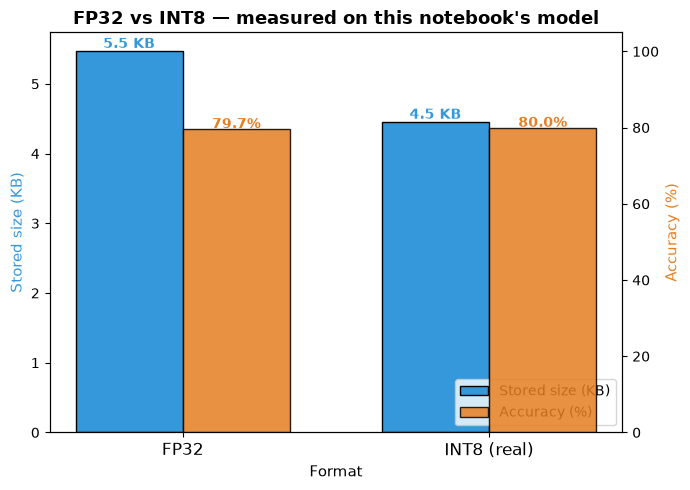

In [5]:
# Chart the MEASURED numbers from the two cells above
import matplotlib.pyplot as plt
import numpy as np

# Collect the measured sizes (KB) and accuracies (%) from the previous cells.
formats    = ['FP32', 'INT8 (real)']
sizes_kb   = [size_fp32 / 1024, size_real / 1024]
accuracies = [acc_fp32 * 100, acc_real * 100]

x = np.arange(len(formats))
width = 0.35

# Twin y-axes: bars for stored size on the left axis, accuracy on the right.
fig, ax1 = plt.subplots(figsize=(7, 5))
ax2 = ax1.twinx()

bars1 = ax1.bar(x - width/2, sizes_kb, width, label='Stored size (KB)', color='#3498db', edgecolor='black')
bars2 = ax2.bar(x + width/2, accuracies, width, label='Accuracy (%)', color='#e67e22', edgecolor='black', alpha=0.85)

# Label every bar with its exact measured value.
for bar, val in zip(bars1, sizes_kb):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.1f} KB', ha='center', fontsize=10, fontweight='bold', color='#3498db')
for bar, val in zip(bars2, accuracies):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold', color='#e67e22')

ax1.set_xlabel('Format', fontsize=11)
ax1.set_ylabel('Stored size (KB)', color='#3498db', fontsize=11)
ax2.set_ylabel('Accuracy (%)', color='#e67e22', fontsize=11)
ax1.set_title('FP32 vs INT8 — measured on this notebook\'s model', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(formats, fontsize=12)
ax2.set_ylim(0, 105)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

## 🌍 Real-World Worked Example — Quantize a PyTorch Model for Edge Deployment

**Industry context:**
- **The result that made "put the model on the phone" routine:** Deep Compression (Han, Mao & Dally, ICLR 2016) reported reducing storage "by 35× to 49× without affecting their accuracy" — AlexNet 240 MB → 6.9 MB, VGG-16 552 MB → 11.3 MB.
- Both mainstream edge runtimes ship an INT8 path: TensorFlow Lite and NVIDIA TensorRT.
- **Whether INT8 is *faster* depends on whether the target chip has integer tensor units.** The size win is guaranteed; the speed win is not — which is why the cell below measures instead of assuming.

We quantize a bigger model and *measure* everything: stored size shrinks, accuracy barely moves, and speed **depends on the hardware** (on a laptop CPU the INT8 overhead can even make it slower — we measure instead of assuming).

In [6]:
# WHAT: repeat the full quantization measurement on a bigger digits model - accuracy, size, latency.
# WHY: layer size changes the verdict - bigger layers get closer to the ideal 4x size and speed gains.
import torch, torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os, time, warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)

# Train the FP32 baseline on the sklearn digits dataset.
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()
Xd, yd = digits.data.astype(np.float32), digits.target
Xtr, Xte, Ytr, Yte = train_test_split(Xd, yd, test_size=0.2, random_state=42)
sc = StandardScaler().fit(Xtr)
Xtr = torch.tensor(sc.transform(Xtr), dtype=torch.float32); Ytr = torch.tensor(Ytr)
Xte = torch.tensor(sc.transform(Xte), dtype=torch.float32); Yte = torch.tensor(Yte)

# The 'big' model: three hidden layers of 128/64 units.
big = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
)
opt = torch.optim.Adam(big.parameters(), lr=1e-3)
for _ in range(100):
    loss = nn.CrossEntropyLoss()(big(Xtr), Ytr)
    opt.zero_grad(); loss.backward(); opt.step()
big.eval()

with torch.no_grad():
    acc_big = (big(Xte).argmax(1)==Yte).float().mean().item()
print(f"FP32 model accuracy: {acc_big*100:.1f}%")

# ── REAL dynamic quantization ─────────────────────────────────────────────
if 'qnnpack' in torch.backends.quantized.supported_engines:
    torch.backends.quantized.engine = 'qnnpack'
big_int8 = torch.quantization.quantize_dynamic(big, {nn.Linear}, dtype=torch.qint8)
with torch.no_grad():
    acc_big8 = (big_int8(Xte).argmax(1)==Yte).float().mean().item()
print(f"INT8 model accuracy: {acc_big8*100:.1f}%  (change: {(acc_big8-acc_big)*100:+.2f} points)")

# ── Measured size ─────────────────────────────────────────────────────────
torch.save(big.state_dict(),      '/tmp/model_fp32.pt')
torch.save(big_int8.state_dict(), '/tmp/model_int8.pt')
kb32 = os.path.getsize('/tmp/model_fp32.pt') / 1024
kb8  = os.path.getsize('/tmp/model_int8.pt') / 1024
print(f"\nStored size (measured): FP32 {kb32:.1f} KB -> INT8 {kb8:.1f} KB ({kb32/kb8:.1f}x smaller)")

# ── Measured latency ──────────────────────────────────────────────────────
N = 1000
start = time.perf_counter()
for _ in range(N):
    with torch.no_grad(): big(Xte)
fp32_ms = (time.perf_counter()-start)*1000/N
start = time.perf_counter()
for _ in range(N):
    with torch.no_grad(): big_int8(Xte)
int8_ms = (time.perf_counter()-start)*1000/N

ratio = fp32_ms / int8_ms
print(f"Latency (measured):     FP32 {fp32_ms:.3f} ms/batch  INT8 {int8_ms:.3f} ms/batch", end="  ")
if ratio >= 1.05:
    print(f"-> INT8 is {ratio:.1f}x faster here")
else:
    print(f"-> INT8 is {1/ratio:.1f}x SLOWER here")
    print("Why: on this CPU the per-call quantize/dequantize overhead outweighs the gain")
    print("for these layer sizes. INT8 speedups appear on hardware with native INT8")
    print("kernels (phone NPUs, edge accelerators) and on much larger models.")

print("\nTakeaway: size reduction is guaranteed; speed is hardware-dependent — benchmark")
print("on the target device. (4-bit methods like GPTQ compress LLMs further still.)")

FP32 model accuracy: 96.7%
INT8 model accuracy: 96.7%  (change: +0.00 points)

Stored size (measured): FP32 70.2 KB -> INT8 22.2 KB (3.2x smaller)


Latency (measured):     FP32 0.068 ms/batch  INT8 0.173 ms/batch  -> INT8 is 2.6x SLOWER here
Why: on this CPU the per-call quantize/dequantize overhead outweighs the gain
for these layer sizes. INT8 speedups appear on hardware with native INT8
kernels (phone NPUs, edge accelerators) and on much larger models.

Takeaway: size reduction is guaranteed; speed is hardware-dependent — benchmark
on the target device. (4-bit methods like GPTQ compress LLMs further still.)


## 💬 Discuss

1. The same technique measured **1.2×** here and **3.9×** in notebook `05`. What does that tell you about quoting a compression ratio from a paper, a blog post, or a vendor datasheet? Write the caveat you would attach to any such number.
2. Our FP32 baseline accuracy was **0.797** on synthetic data. Would you trust a quantization accuracy comparison measured at 0.797? What would you insist on before running the comparison at all?
3. Size down 3.2×, latency up 2.7× (notebook `04`). Write the one-sentence recommendation you would give a team shipping to (a) a Raspberry Pi with no accelerator and (b) a modern phone with a neural engine. Explain why the two sentences differ.


## ⚠️ Where this breaks

**This notebook's own three numbers are the lesson. Read them before you quote anyone's compression ratio.**

- **Our measured shrink was 1.2×, not 4×** — 5,597 bytes down to 4,557. The theoretical 4× applies only to the quantized *weight tensors*; scales, zero-points, biases and the model's structural overhead all stay float32, and on a model this small the overhead dominates. Notebook `05` measured **3.9×** on a larger model — same technique, different answer, because the weights were a bigger share of the file.
- **The simulation shrank nothing at all** — 5,597 bytes both times — because rounding weights to 256 levels while still *storing* them as float32 changes the values, not the bytes. Two different things are called "quantization" and only one of them makes the file smaller. Know which one someone means before you agree to it.
- **Smaller does not mean faster.** Notebook `04` measures it on this same machine: INT8 was **2.7× slower** than FP32, because per-call quantize/dequantize overhead outweighed the gain for small layers on a CPU with no native INT8 kernels. The speed-up is a property of the *hardware*, not of the technique.
- **Dynamic quantization only touches the weights of `Linear`/LSTM layers** and computes activation scales at run time. Convolutions and activations are untouched — so on a CNN the win is far smaller than on an MLP or a transformer. Check which layers dominate your model before you promise anything.
- **Accuracy is not always free.** 4-bit compression of large models is a recoverable loss, not a free lunch: 2026 practice adds an explicit healing/recovery step after compression (Ryskulov et al. 2026, arXiv 2608.20953). If someone tells you "just quantize it", ask what they measured afterwards, and on what.
- **The assumption that must hold:** your weight distribution is well-behaved enough for a single scale per tensor. Heavy outliers break that assumption, which is why per-channel and mixed-precision schemes exist.
- **Cheaper alternative:** check whether **FP16** is enough first. It halves the size, is supported almost everywhere, and usually costs no measurable accuracy — no calibration, no INT8 kernel hunting.


## 🧩 Mini-exercise

**Try it:** Run inference with both the FP32 model and the real INT8 model on 10 samples (`model(X[:10]).argmax(1)` vs `model_int8_real(X[:10]).argmax(1)`) and compare the predicted classes. Do they match exactly or only approximately?

---

## Summary
**What you did:** Built a small PyTorch model, quantized it two ways — a 256-level weight-rounding simulation (accuracy effect) and real INT8 dynamic quantization (measured size reduction) — and charted the measured sizes and accuracies. The worked example repeated this on a bigger model and also measured latency honestly.

**In real life you'd also:** Use quantization-aware training to limit accuracy drop, benchmark on the target device, and (for TensorFlow) export TFLite INT8/FP16 for mobile deployment.

**The main idea:** Quantization reduces precision (FP32 → INT8) to shrink the model; the size win is guaranteed, the speed win depends on hardware support.

**Next:** `06_flask_fastapi_deployment.ipynb` shows how to serve a model via a REST API with Flask/FastAPI.


## 🔭 State of the field (2026)

INT8 is no longer the interesting boundary. For large models the 2026 default is 4-bit weights, made deployable by activation-aware schemes that protect the small fraction of weights that matter most (AWQ, arXiv 2306.00978) rather than rounding everything equally. Two 2026 refinements matter for honesty: 4-bit is a *recoverable loss, not a free lunch*, and there are now published recipes for repairing a compressed model instead of shipping it as-is (arXiv 2608.20953); and precision is starting to be chosen per tile of the computation rather than per tensor or per layer (arXiv 2608.17336).

**Why this notebook's small, awkward numbers are the point.** You measured 1.2× shrink where the theory promises 4×, and notebook `04` measured a model that got 3.2× smaller and 2.7× *slower*. That gap between the advertised ratio and the measured one is exactly what the quantization-healing literature exists to close, and the habit of measuring size, accuracy and latency separately on the target device is what makes you able to read those papers critically. The mechanism — map floats onto a small integer grid, keep a scale, accept rounding error — is identical at 8 bits and at 4.


## 📚 References

1. Jacob, B. et al. (2018). *Quantization and Training of Neural Networks for Efficient Integer-Arithmetic-Only Inference*. CVPR. https://arxiv.org/abs/1712.05877
2. Han, S., Mao, H. & Dally, W. J. (2016). *Deep Compression: Compressing Deep Neural Networks with Pruning, Trained Quantization and Huffman Coding*. ICLR. https://arxiv.org/abs/1510.00149
3. Gholami, A. et al. (2021). *A Survey of Quantization Methods for Efficient Neural Network Inference*. arXiv. https://arxiv.org/abs/2103.13630
4. Frantar, E., Ashkboos, S., Hoefler, T. & Alistarh, D. (2023). *GPTQ: Accurate Post-Training Quantization for Generative Pre-trained Transformers*. ICLR. https://arxiv.org/abs/2210.17323

**Recent work (2023–2026)**

5. Lin et al. (2023). *AWQ: Activation-aware Weight Quantization for LLM Compression and Acceleration*. arXiv. https://arxiv.org/abs/2306.00978 — the activation-aware low-bit weight quantization that shipped almost everywhere; it protects the small fraction of weights that matter most instead of rounding all of them equally.
6. Ryskulov et al. (2026). *Quantization-Aware Healing: A Practical Recipe for Recovering Compressed, 4-Bit LLMs*. arXiv. https://arxiv.org/abs/2608.20953 — 4-bit is a recoverable loss, not a free lunch — a practical recipe for repairing a compressed model rather than shipping it as-is.
7. Zhang et al. (2026). *TileMix: Tile-Centric Mixed-Precision Attention for LLM Inference Acceleration*. arXiv. https://arxiv.org/abs/2608.17336 — where mixed precision is heading: precision chosen per tile of the computation rather than per tensor or per layer.
